In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("C:/Users/HomePC/Desktop/My sql projects/Project 2/Life-Expectancy-Data-Updated.csv")
df.head(10)

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7
5,Costa Rica,Central America and Caribbean,2006,9.8,11.2,95.2200,4.19,88,86,26.4,...,89,0.16,9110,4.35,2.0,1.9,7.9,0,1,78.2
6,Russian Federation,Rest of Europe,2015,6.6,8.2,223.0000,8.06,97,97,26.2,...,97,0.08,9313,144.10,2.3,2.3,12.0,0,1,71.2
7,Hungary,European Union,2000,8.7,10.1,192.9690,12.23,88,99,25.9,...,99,0.08,8971,10.21,2.3,2.3,10.2,1,0,71.2
8,Jordan,Middle East,2001,22.0,26.1,129.7640,0.52,97,87,27.9,...,99,0.13,3708,5.22,4.0,3.9,9.6,0,1,71.9
9,Moldova,Rest of Europe,2008,15.3,17.8,217.8570,7.72,97,92,26.5,...,90,0.43,2235,2.87,2.9,3.1,10.9,0,1,68.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   object 
 1   Region                       2864 non-null   object 
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita    

In [5]:
df.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,2007.500000,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.206704,0.793296,68.856075
std,4.610577,27.538117,44.569974,114.910281,3.981949,15.995511,18.659693,2.193905,15.080365,15.534225,2.381389,16934.788931,136.485867,4.438234,4.525217,3.171556,0.405012,0.405012,9.405608
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.750000,8.100000,9.675000,106.910250,1.200000,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1415.750000,2.097500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.600000,23.100000,163.841500,4.020000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4217.000000,7.850000,3.300000,3.400000,7.800000,0.000000,1.000000,71.400000
75%,2011.250000,47.350000,66.000000,246.791375,7.777500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12557.000000,23.687500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000


In [9]:
# Check for Missing Values
df.isnull().sum()

Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status_Developed       0
Economy_status_Developing      0
Life_expectancy                0
dtype: int64

In [7]:
#Handle Missing Values (if any)
imputer = SimpleImputer(strategy='mean')

## Correlation Analysis

In [35]:
cor_1=df[['Life_expectancy', 'GDP_per_capita','Schooling']]
correlation_matrix = cor_1.corr()
correlation_matrix

,Life_expectancy,GDP_per_capita,Schooling
Life_expectancy,1.000000,0.583090,0.732484
GDP_per_capita,0.583090,1.000000,0.580626
Schooling,0.732484,0.580626,1.000000


In [36]:
cor_2=df[['Polio','Infant_deaths', 'Under_five_deaths','Adult_mortality']]
correlation_matrix = cor_2.corr()
correlation_matrix

,Polio,Infant_deaths,Under_five_deaths,Adult_mortality
Polio,1.000000,-0.740790,-0.742983,-0.524226
Infant_deaths,-0.740790,1.000000,0.985651,0.794661
Under_five_deaths,-0.742983,0.985651,1.000000,0.802361
Adult_mortality,-0.524226,0.794661,0.802361,1.000000


In [37]:
cor_3=df[['Incidents_HIV','Alcohol_consumption','Adult_mortality']]
correlation_matrix = cor_3.corr()
correlation_matrix

,Incidents_HIV,Alcohol_consumption,Adult_mortality
Incidents_HIV,1.000000,-0.034118,0.699119
Alcohol_consumption,-0.034118,1.000000,-0.244794
Adult_mortality,0.699119,-0.244794,1.000000


## Predictive Model

In [11]:
# Target Variable & Feature Variables
y = df['Life_expectancy']
X = df[[
    'Infant_deaths',
    'Under_five_deaths',
    'Adult_mortality',
    'Alcohol_consumption',
    'Hepatitis_B',
    'Measles',
    'BMI',
    'Polio',
    'Diphtheria',
    'Incidents_HIV',
    'GDP_per_capita',
    'Population_mln',
    'Thinness_ten_nineteen_years',
    'Thinness_five_nine_years',
    'Schooling'
]]

In [17]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Handle Missing Data Properly
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [20]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
#Train the Model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)


In [28]:
# Evaluate Model

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.094160128941377


In [29]:
#RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.364545222810347


In [30]:
#R² Score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.9775640841520287


In [32]:
# Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("R²:", r2_score(y_test, rf_pred))

R²: 0.997144742465234


In [33]:
#Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance)

                        Feature  Importance
1             Under_five_deaths    0.743485
2               Adult_mortality    0.228504
0                 Infant_deaths    0.012072
11               Population_mln    0.002484
10               GDP_per_capita    0.002298
3           Alcohol_consumption    0.002285
9                 Incidents_HIV    0.001705
6                           BMI    0.001634
14                    Schooling    0.001342
12  Thinness_ten_nineteen_years    0.000980
13     Thinness_five_nine_years    0.000966
5                       Measles    0.000648
7                         Polio    0.000539
8                    Diphtheria    0.000530
4                   Hepatitis_B    0.000528


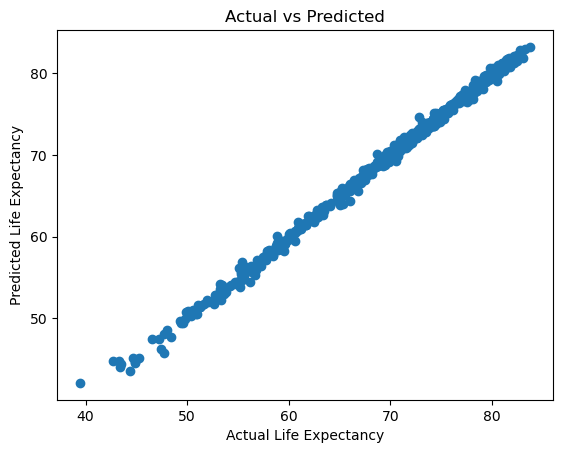

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted")
plt.show()